In [2]:
try:
    import dolfinx
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenicsx-install-release-real.sh" \
        -O "/tmp/fenicsx-install.sh"
    !bash "/tmp/fenicsx-install.sh"
    import dolfinx

print("FEniCSx version:", dolfinx.__version__)

--2026-08-26 13:02:30--  https://fem-on-colab.github.io/releases/fenicsx-install-release-real.sh
Resolving fem-on-colab.github.io (fem-on-colab.github.io)... 185.199.110.153, 185.199.111.153, 185.199.109.153, ...
Connecting to fem-on-colab.github.io (fem-on-colab.github.io)|185.199.110.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4339 (4.2K) [application/x-sh]
Saving to: ‘/tmp/fenicsx-install.sh’

/tmp/fenicsx-instal 100%[===================>]   4.24K  --.-KB/s    in 0s      

2026-08-26 13:02:30 (40.2 MB/s) - ‘/tmp/fenicsx-install.sh’ saved [4339/4339]

+ INSTALL_PREFIX=/usr/local
++ awk -F/ '{print NF-1}'
++ echo /usr/local
+ INSTALL_PREFIX_DEPTH=2
+ PROJECT_NAME=fem-on-colab
+ SHARE_PREFIX=/usr/local/share/fem-on-colab
+ FENICSX_INSTALLED=/usr/local/share/fem-on-colab/fenicsx.installed
+ [[ ! -f /usr/local/share/fem-on-colab/fenicsx.installed ]]
+ PYBIND11_INSTALL_SCRIPT_PATH=https://github.com/fem-on-colab/fem-on-colab.github.io/raw/d829ee18/release

In [4]:
from mpi4py import MPI
import dolfinx

print("FEniCSx version:", dolfinx.__version__)
print("MPI processes:", MPI.COMM_WORLD.size)

FEniCSx version: 0.11.0.post0
MPI processes: 1


In [5]:
!pip -q install meshio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.2/166.2 kB 4.4 MB/s eta 0:00:00


EA = 3.499734e+02 N
Segment stiffness = 1.049920e+04 N/m
Internal nodal mass = 2.539454e-05 kg
Progress:   5.0% | t = 0.1000 s | max(lambda) = 1.000004 | max(T) = 1.470236e-03 N
Progress:  10.0% | t = 0.2000 s | max(lambda) = 1.000017 | max(T) = 6.113595e-03 N
Progress:  15.0% | t = 0.3000 s | max(lambda) = 1.000041 | max(T) = 1.443558e-02 N
Progress:  20.0% | t = 0.4000 s | max(lambda) = 1.000083 | max(T) = 2.896723e-02 N
Progress:  25.0% | t = 0.5000 s | max(lambda) = 1.000141 | max(T) = 4.931046e-02 N
Progress:  30.0% | t = 0.6000 s | max(lambda) = 1.000204 | max(T) = 7.136327e-02 N
Progress:  35.0% | t = 0.7000 s | max(lambda) = 1.000294 | max(T) = 1.030218e-01 N
Progress:  40.0% | t = 0.8000 s | max(lambda) = 1.000378 | max(T) = 1.322318e-01 N
Progress:  45.0% | t = 0.9000 s | max(lambda) = 1.000441 | max(T) = 1.543405e-01 N
Progress:  50.0% | t = 1.0000 s | max(lambda) = 1.000456 | max(T) = 1.597188e-01 N
Progress:  55.0% | t = 1.1000 s | max(lambda) = 1.000464 | max(T) = 1.62264

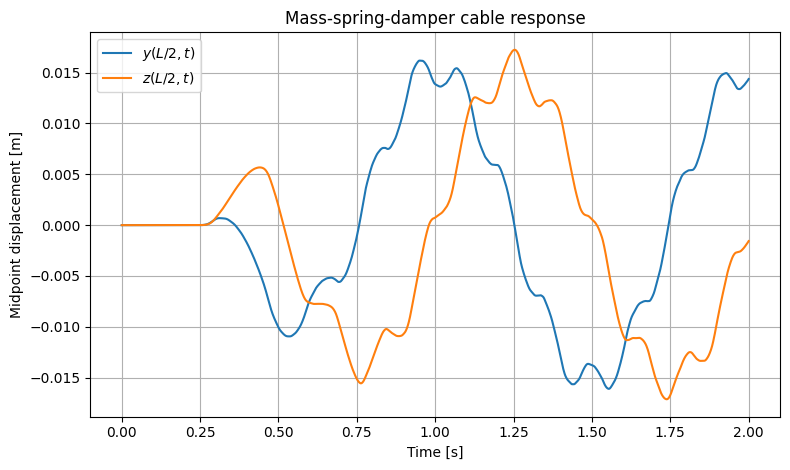

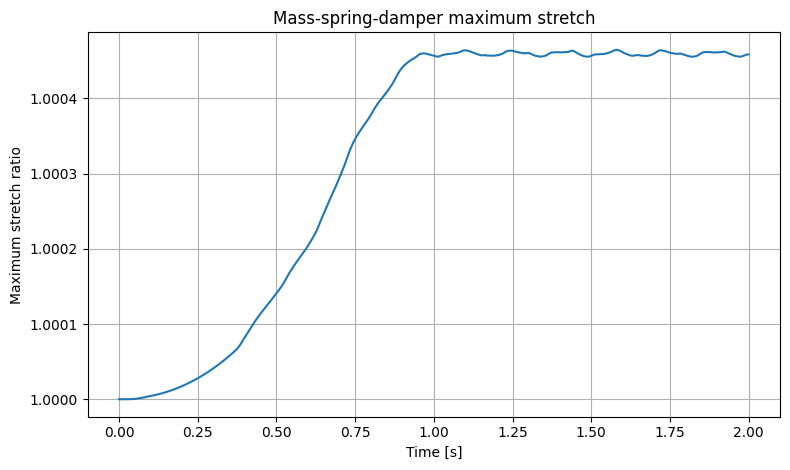

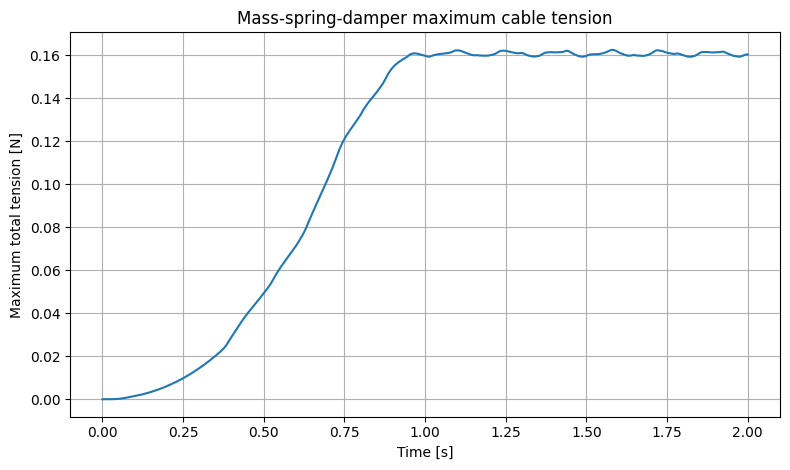

Simulation completed.
ParaView file: mass_spring_cable_vtk/mass_spring_cable_motion.pvd
Download archive: mass_spring_cable_vtk.zip
Open the PVD file directly; its geometry is already deformed.


In [6]:
import os
import shutil
import zipfile
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. GEOMETRY AND MATERIAL
# ============================================================

L = 1.0                         # cable length [m]
Nx = 31                         # number of lumped nodes
X = np.linspace(0.0, L, Nx)
l0 = L / (Nx - 1)               # unstretched segment length [m]

E = 4.456e8                     # Young's modulus [Pa]
diameter = 1.0e-3               # cable diameter [m]
A = np.pi * diameter**2 / 4.0   # cross-sectional area [m^2]
rho = 970.0                     # density [kg/m^3]
rhoA = rho * A                  # mass per unit length [kg/m]
EA = E * A                      # axial rigidity [N]

k_segment = EA / l0             # stiffness of one discrete spring [N/m]
c_edge = 1.0e-6                 # axial dashpot coefficient [N s/m]
c_node = 1.0e-6                 # nodal damping coefficient [N s/m]

# Assemble lumped masses: half of each adjacent segment mass.
m_node = np.zeros(Nx)
segment_mass = rhoA * l0
for e in range(Nx - 1):
    m_node[e] += 0.5 * segment_mass
    m_node[e + 1] += 0.5 * segment_mass

print(f"EA = {EA:.6e} N")
print(f"Segment stiffness = {k_segment:.6e} N/m")
print(f"Internal nodal mass = {m_node[1]:.6e} kg")

# ============================================================
# 2. TIME AND BOUNDARY EXCITATION
# ============================================================

Tend = 2.0                      # use 0.25 for a quick test [s]
dt = 2.0e-5                     # explicit time step [s]
save_every = 500                # one ParaView frame per 500 steps

number_of_steps = int(round(Tend / dt))
time = np.arange(number_of_steps + 1, dtype=float) * dt

amplitude = 0.03 * L
omega = 2.0 * np.pi             # 1 Hz circular excitation
Tramp = 1.0


def ramp_and_rate(t):
    if t <= Tramp:
        ramp = 0.5 * (1.0 - np.cos(np.pi * t / Tramp))
        ramp_rate = 0.5 * (np.pi / Tramp) * np.sin(np.pi * t / Tramp)
    else:
        ramp = 1.0
        ramp_rate = 0.0
    return ramp, ramp_rate


def right_boundary_motion(t):
    ramp, ramp_rate = ramp_and_rate(t)
    c = np.cos(omega * t)
    s = np.sin(omega * t)

    position = np.array([
        L,
        amplitude * ramp * c,
        amplitude * ramp * s,
    ])

    velocity = np.array([
        0.0,
        amplitude * (ramp_rate * c - ramp * omega * s),
        amplitude * (ramp_rate * s + ramp * omega * c),
    ])
    return position, velocity


# ============================================================
# 3. STATE AND RESULT ARRAYS
# ============================================================

reference_position = np.column_stack((X, np.zeros(Nx), np.zeros(Nx)))
position = reference_position.copy()
velocity = np.zeros((Nx, 3))

midpoint = Nx // 2
mid_y = np.zeros(number_of_steps + 1)
mid_z = np.zeros(number_of_steps + 1)
max_stretch = np.ones(number_of_steps + 1)
max_tension = np.zeros(number_of_steps + 1)

# ============================================================
# 4. PARAVIEW VTU/PVD WRITER
# ============================================================

output_folder = "mass_spring_cable_vtk"
if os.path.exists(output_folder):
    shutil.rmtree(output_folder)
os.makedirs(output_folder)

pvd_entries = []


def array_text(a):
    return " ".join(f"{value:.16e}" for value in np.asarray(a).ravel())


def write_vtu(frame, t, current_position, tension):
    """Write one serial ASCII VTU file containing line elements."""
    displacement = current_position - reference_position
    connectivity = np.column_stack(
        (np.arange(Nx - 1), np.arange(1, Nx))
    ).ravel()
    offsets = 2 * np.arange(1, Nx)
    cell_types = np.full(Nx - 1, 3)  # VTK_LINE

    filename = f"mass_spring_cable_{frame:06d}.vtu"
    path = os.path.join(output_folder, filename)

    xml = f'''<?xml version="1.0"?>
<VTKFile type="UnstructuredGrid" version="0.1" byte_order="LittleEndian">
  <UnstructuredGrid>
    <Piece NumberOfPoints="{Nx}" NumberOfCells="{Nx - 1}">
      <PointData Vectors="Displacement">
        <DataArray type="Float64" Name="Displacement" NumberOfComponents="3" format="ascii">
          {array_text(displacement)}
        </DataArray>
        <DataArray type="Float64" Name="Velocity" NumberOfComponents="3" format="ascii">
          {array_text(velocity)}
        </DataArray>
      </PointData>
      <CellData Scalars="Tension">
        <DataArray type="Float64" Name="Tension" format="ascii">
          {array_text(tension)}
        </DataArray>
      </CellData>
      <Points>
        <DataArray type="Float64" NumberOfComponents="3" format="ascii">
          {array_text(current_position)}
        </DataArray>
      </Points>
      <Cells>
        <DataArray type="Int32" Name="connectivity" format="ascii">
          {' '.join(map(str, connectivity))}
        </DataArray>
        <DataArray type="Int32" Name="offsets" format="ascii">
          {' '.join(map(str, offsets))}
        </DataArray>
        <DataArray type="UInt8" Name="types" format="ascii">
          {' '.join(map(str, cell_types))}
        </DataArray>
      </Cells>
    </Piece>
  </UnstructuredGrid>
</VTKFile>
'''
    with open(path, "w", encoding="utf-8") as file:
        file.write(xml)
    pvd_entries.append((t, filename))


def write_pvd():
    datasets = "\n".join(
        f'    <DataSet timestep="{t:.16e}" group="" part="0" file="{name}"/>'
        for t, name in pvd_entries
    )
    content = f'''<?xml version="1.0"?>
<VTKFile type="Collection" version="0.1" byte_order="LittleEndian">
  <Collection>
{datasets}
  </Collection>
</VTKFile>
'''
    with open(os.path.join(output_folder, "mass_spring_cable_motion.pvd"),
              "w", encoding="utf-8") as file:
        file.write(content)


# Initial frame
write_vtu(0, 0.0, position, np.zeros(Nx - 1))
frame = 1

# ============================================================
# 5. EXPLICIT MASS-SPRING-DAMPER TIME INTEGRATION
# ============================================================

for step in range(1, number_of_steps + 1):
    t = time[step]

    # Exact prescribed boundary states at the new time.
    position[0] = (0.0, 0.0, 0.0)
    velocity[0] = (0.0, 0.0, 0.0)
    position[-1], velocity[-1] = right_boundary_motion(t)

    force = np.zeros((Nx, 3))
    stretch_values = np.ones(Nx - 1)
    tension_values = np.zeros(Nx - 1)

    # Vectorized spring-damper forces for every cable segment.
    segment_vector = position[1:] - position[:-1]
    segment_length = np.linalg.norm(segment_vector, axis=1)
    safe_length = np.maximum(segment_length, 1.0e-14)
    tangent = segment_vector / safe_length[:, None]

    relative_velocity = velocity[1:] - velocity[:-1]
    length_rate = np.sum(relative_velocity * tangent, axis=1)
    stretch_values = segment_length / l0

    # Tension-only Kelvin-Voigt spring-damper law. The geometric extension
    # gate prevents the dashpot from transmitting force in a slack segment.
    trial_tension = (
        k_segment * (segment_length - l0)
        + c_edge * length_rate
    )
    tension_values = np.where(
        segment_length > l0,
        np.maximum(trial_tension, 0.0),
        0.0,
    )

    edge_force = tension_values[:, None] * tangent
    np.add.at(force, np.arange(Nx - 1), edge_force)
    np.add.at(force, np.arange(1, Nx), -edge_force)

    # Small damping and symplectic-Euler update of free internal masses.
    force[1:-1] -= c_node * velocity[1:-1]
    acceleration = force[1:-1] / m_node[1:-1, None]
    velocity[1:-1] += dt * acceleration
    position[1:-1] += dt * velocity[1:-1]

    # Reapply boundaries so they remain exact after every step.
    position[0] = (0.0, 0.0, 0.0)
    velocity[0] = (0.0, 0.0, 0.0)
    position[-1], velocity[-1] = right_boundary_motion(t)

    # Recalculate output quantities from the updated configuration.
    updated_vector = position[1:] - position[:-1]
    updated_length = np.linalg.norm(updated_vector, axis=1)
    updated_tangent = updated_vector / np.maximum(
        updated_length[:, None], 1.0e-14
    )
    updated_rate = np.sum(
        (velocity[1:] - velocity[:-1]) * updated_tangent, axis=1
    )
    stretch_values = updated_length / l0
    tension_values = np.where(
        updated_length > l0,
        np.maximum(
            k_segment * (updated_length - l0) + c_edge * updated_rate,
            0.0,
        ),
        0.0,
    )

    mid_y[step] = position[midpoint, 1]
    mid_z[step] = position[midpoint, 2]
    max_stretch[step] = np.max(stretch_values)
    max_tension[step] = np.max(tension_values)

    if step % save_every == 0 or step == number_of_steps:
        write_vtu(frame, t, position, tension_values)
        frame += 1

    if step % max(1, number_of_steps // 20) == 0:
        print(
            f"Progress: {100.0 * step / number_of_steps:5.1f}% | "
            f"t = {t:.4f} s | max(lambda) = {max_stretch[step]:.6f} | "
            f"max(T) = {max_tension[step]:.6e} N"
        )

write_pvd()

# Save numerical histories.
np.savez(
    "mass_spring_cable_results.npz",
    time=time,
    mid_y=mid_y,
    mid_z=mid_z,
    max_stretch=max_stretch,
    max_tension=max_tension,
    nodal_mass=m_node,
    k_segment=k_segment,
    c_edge=c_edge,
    c_node=c_node,
)

# Zip all ParaView files for convenient Colab download.
zip_name = "mass_spring_cable_vtk.zip"
with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as archive:
    for name in sorted(os.listdir(output_folder)):
        archive.write(os.path.join(output_folder, name), arcname=name)

# ============================================================
# 6. PLOTS
# ============================================================

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(time, mid_y, label=r"$y(L/2,t)$")
ax.plot(time, mid_z, label=r"$z(L/2,t)$")
ax.set(xlabel="Time [s]", ylabel="Midpoint displacement [m]",
       title="Mass-spring-damper cable response")
ax.grid(True)
ax.legend()
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(time, max_stretch)
ax.set(xlabel="Time [s]", ylabel="Maximum stretch ratio",
       title="Mass-spring-damper maximum stretch")
ax.ticklabel_format(axis="y", style="plain", useOffset=False)
ax.grid(True)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(time, max_tension)
ax.set(xlabel="Time [s]", ylabel="Maximum total tension [N]",
       title="Mass-spring-damper maximum cable tension")
ax.grid(True)
fig.tight_layout()
plt.show()

print("Simulation completed.")
print(f"ParaView file: {output_folder}/mass_spring_cable_motion.pvd")
print(f"Download archive: {zip_name}")
print("Open the PVD file directly; its geometry is already deformed.")


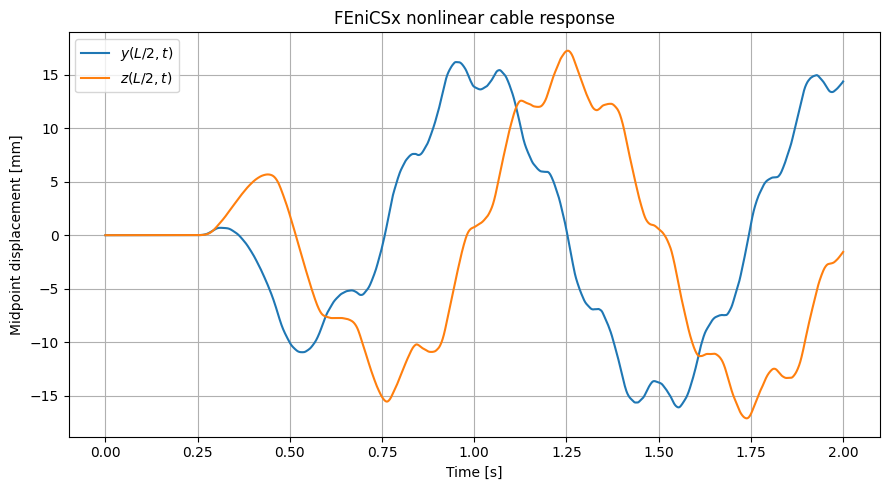

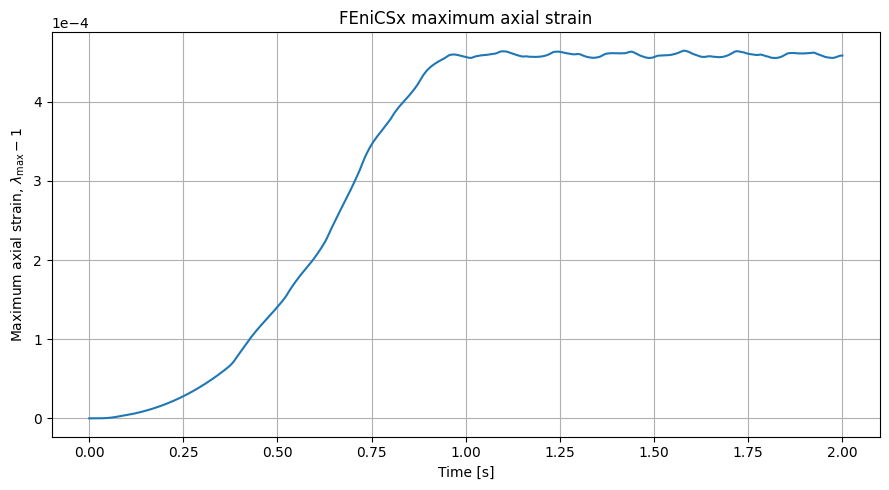

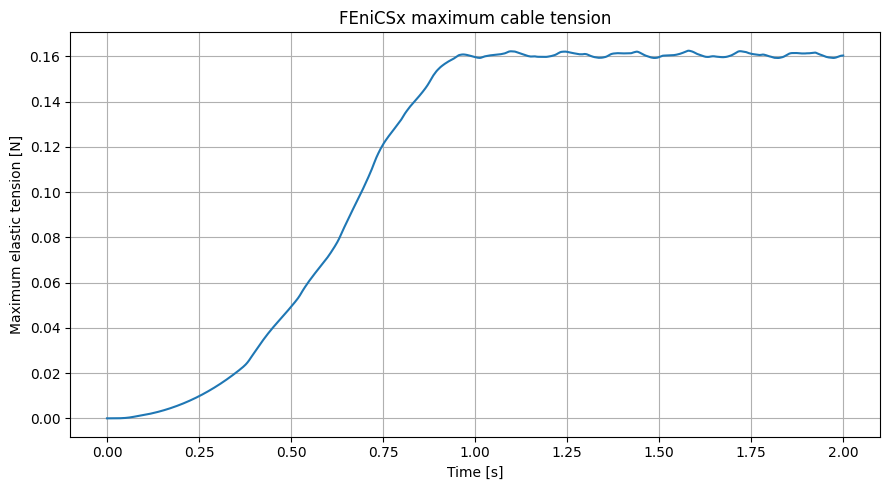

In [9]:
# Midpoint displacement in millimetres
plt.figure(figsize=(9, 5))

plt.plot(time, 1e3 * mid_y, label=r"$y(L/2,t)$")
plt.plot(time, 1e3 * mid_z, label=r"$z(L/2,t)$")

plt.xlabel("Time [s]")
plt.ylabel("Midpoint displacement [mm]")
plt.title("FEniCSx nonlinear cable response")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Maximum axial strain
maximum_strain = max_stretch - 1.0

plt.figure(figsize=(9, 5))

plt.plot(time, maximum_strain)

plt.xlabel("Time [s]")
plt.ylabel(r"Maximum axial strain, $\lambda_{\max}-1$")
plt.title("FEniCSx maximum axial strain")
plt.ticklabel_format(
    axis="y",
    style="scientific",
    scilimits=(0, 0)
)
plt.grid(True)
plt.tight_layout()
plt.show()

# Maximum elastic tension
plt.figure(figsize=(9, 5))

plt.plot(time, max_tension)

plt.xlabel("Time [s]")
plt.ylabel("Maximum elastic tension [N]")
plt.title("FEniCSx maximum cable tension")
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
shutil.make_archive(
    "mass_spring_cable_vtk",
    "zip",
    "mass_spring_cable_vtk"
)

from google.colab import files
files.download("mass_spring_cable_vtk.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>